In [6]:
import pandas as pd
import numpy as np
import gzip

# ClinVar veritabanından indirilen sıkıştırılmış VCF dosyasının yolu
vcf_file = "clinvar.vcf.gz"
"""
 VCF dosyasının header satırlarını atlayarak, 
 kolon isimlerinin bulunduğu '#CHROM' satırını yakalayan fonksiyon.
 """
def get_vcf_names(vcf_path):
    with gzip.open(vcf_path, "rt") as ifile:
        for line in ifile:
            if line.startswith("#CHROM"):
                vcf_names = line.strip().split('\t')
                return vcf_names

names = get_vcf_names(vcf_file)

In [7]:
# Tüm kolonları yüklemek yerine sadece analizde kullanılacak temel varyant kolonlarını seçiyoruz
use_cols = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'INFO']
df = pd.read_csv(vcf_file, compression='gzip', sep='\t', comment='#', names=names, usecols=use_cols)

C:\Users\melda\AppData\Local\Temp\ipykernel_20996\1642033258.py:3: DtypeWarning: Columns (0: #CHROM) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(vcf_file, compression='gzip', sep='\t', comment='#', names=names, usecols=use_cols)


In [8]:
# VCF formatındaki 'INFO' kolonu tüm bilgileri bitişik halde tutar. Düzenli İfadeler
# kullanarak bu string içerisinden ihtiyacımız olan özellikleri ayrı kolonlar olarak çıkarıyoruz.
df['CLNSIG'] = df['INFO'].str.extract(r'CLNSIG=([^;]+)')         # Klinik anlam Patojenik/Benign
df['CLNREVSTAT'] = df['INFO'].str.extract(r'CLNREVSTAT=([^;]+)') # Değerlendirme güvenilirliği Yıldız seviyesi
df['MC'] = df['INFO'].str.extract(r'MC=([^;]+)')                 # Moleküler sonuç Varyant tipi missense

In [9]:
#vwri kalitesini artırmak için sadece uzman paneli tarafından incelenmiş 
# veya uygulama kılavuzlarına girmiş yüksek güvenilirlikli (3 ve 4 yıldızlı) verileri alıyoruz.
reliable_mask = df['CLNREVSTAT'].str.contains('reviewed_by_expert_panel|practice_guideline', na=False)
df_filtered = df[reliable_mask].copy()

In [10]:
len(df_filtered)

21387

In [11]:
#Sadece 'missense' (yanlış anlamlı) mutasyon tipine sahip varyantları filtreliyoruz.
df_filtered = df_filtered[df_filtered['MC'].str.contains('missense_variant', na=False)]

In [12]:
len(df_filtered)

6045

In [13]:
"""
    Klinik anlam değerlerini makine öğrenmesi için ikili formata çeviren fonksiyon.
    Patojenik (Hastalik yapici) = 1.0
    Benign (İyi huylu/Zararsiz) = 0.0
    """
def get_target(sig):
    
    if pd.isna(sig): return np.nan
    sig_lower = sig.lower()
    
    # İçinde 'pathogenic' geçenleri 1 olarak etiketliyoruz çelişkili durumları dışlayarak
    if ('pathogenic' in sig_lower) and ('benign' not in sig_lower):
        return 1.0
    # İçinde 'benign' geçenleri 0 olarak etiketliyoruz
    elif ('benign' in sig_lower) and ('pathogenic' not in sig_lower):
        return 0.0
    return np.nan 

df_filtered['target'] = df_filtered['CLNSIG'].apply(get_target)
# Belirsiz veya çelişkili olan değerleri NaN olanlar veri setinden çıkarıyoruz
df_filtered = df_filtered.dropna(subset=['target'])

In [14]:
len(df_filtered)

3329

In [15]:
# Modelin varyantların genomik adreslerini ezberlemesini önlemek için, test setinde adresler gizlenecektir.
# Bu nedenle aynı gen üzerindeki varyantların farklı gruplara düşmemesi adına 'GENEINFO' özelliğini çıkarıyoruz.
df_filtered['GENEINFO'] = df['INFO'].str.extract(r'GENEINFO=([^:|;]+)')

print(f"Filtrelenmiş Toplam Varyant Sayısı: {len(df_filtered)}")
print(f"Sınıf Dağılımı:\n{df_filtered['target'].value_counts()}")

Filtrelenmiş Toplam Varyant Sayısı: 3329
Sınıf Dağılımı:
target
1.0    2235
0.0    1094
Name: count, dtype: int64


C:\Users\melda\AppData\Local\Temp\ipykernel_20996\1283049756.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_filtered, palette=['#2ca02c', '#d62728'])


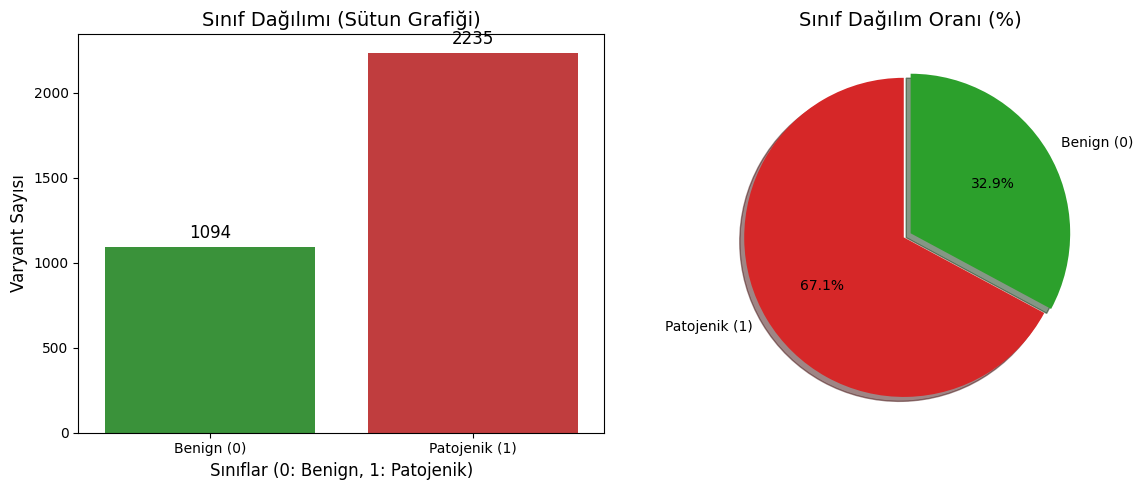

In [ ]:
# Modelin taraf tutmasını (bias) engellemek adına sınıfların ne kadar dengeli olduğunu inceliyoruz.
import matplotlib.pyplot as plt
import seaborn as sns
# Grafik ayarları
plt.figure(figsize=(12, 5))

# Birinci Grafik: Sütun Grafiği 
plt.subplot(1, 2, 1)
ax = sns.countplot(x='target', data=df_filtered, palette=['#2ca02c', '#d62728'])
plt.title('Sınıf Dağılımı (Sütun Grafiği)', fontsize=14)
plt.xlabel('Sınıflar (0: Benign, 1: Patojenik)', fontsize=12)
plt.ylabel('Varyant Sayısı', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Benign (0)', 'Patojenik (1)'])

# Sütunların üzerine sayıları yazdırma
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

# İkinci Grafik: Pasta Grafiği 
plt.subplot(1, 2, 2)
class_counts = df_filtered['target'].value_counts()
plt.pie(class_counts, labels=['Patojenik (1)', 'Benign (0)'], autopct='%1.1f%%', 
        startangle=90, colors=['#d62728','#2ca02c'], explode=(0.05, 0), shadow=True)
plt.title('Sınıf Dağılım Oranı (%)', fontsize=14)

plt.tight_layout()
plt.show()

In [17]:
#Kalıtsal kanser genleri listesi enn yaygın olanları ekliyoruz
cancer_genes = ['BRCA1', 'BRCA2', 'TP53', 'MLH1', 'MSH2', 'MSH6', 'PMS2', 'STK11', 'PTEN', 'APC', 'MUTYH', 'PALB2', 'ATM', 'CHEK2']

#Hangi genin hangi panele ait olduğunu belirleyen fonksiyon
def assign_panel(gene):
    if pd.isna(gene):
        return 'Genel'
    if gene == 'PAH':
        return 'PAH'
    elif gene == 'CFTR':
        return 'CFTR'
    elif gene in cancer_genes:
        return 'Kanser'
    else:
        return 'Genel'

#Panel adında yeni bir sütun oluştur ve fonksiyonu uygula
df_filtered['Panel'] = df_filtered['GENEINFO'].apply(assign_panel)

# Panellere göre Patojenik (1.0) ve Benign (0.0) dağılımını görelim
print("--- Panellere ve Sınıflara Göre Dağılım ---")
panel_distribution = df_filtered.groupby(['Panel', 'target']).size().unstack(fill_value=0)
print(panel_distribution)

# Toplam sayıları kontrol edelim
print(f"\nToplam Varyant Sayısı: {df_filtered.shape[0]}")

--- Panellere ve Sınıflara Göre Dağılım ---
target  0.0   1.0
Panel            
CFTR      0    48
Genel   781  1670
Kanser  313   291
PAH       0   226

Toplam Varyant Sayısı: 3329


In [18]:
""" 
CFTR ve PAH panellerinde hiç 'Benign' (0.0) varyant bulunmamaktadır.
Şartnameye uygun olarak gnomAD'dan (sağlıklı popülasyon veritabanı)
PAH için 200, CFTR için 70 adet rastgele örneklem çekilip Benign (0.0) olarak eklenecektir.
"""
def prepare_gnomad_data(filename, gene, panel, req):
    """
    gnomAD'dan indirilen CSV dosyasını okuyan, kolon isimlerini ClinVar formatına 
    uyarlayan ve istenilen sayıda rastgele Benign örneklem çeken fonksiyon.
    """
    df = pd.read_csv(filename)
    
    # gnomAD kolonlarını ClinVar kolon isimleriyle eşleştiriyoruz
    map_cols = {'Chromosome': '#CHROM', 'Position': 'POS', 'Reference': 'REF', 'Alternate': 'ALT', 'Protein Consequence': 'HGVSp'}
    df = df.rename(columns=lambda x: map_cols.get(x, x))
    
    # Genomik koordinatı eksik olan bozuk verileri siliyoruz
    df = df.dropna(subset=['#CHROM', 'POS', 'REF', 'ALT']).copy()
    
    # gnomAD'dan çekilen sağlıklı popülasyon verilerini Benign (0.0) olarak etiketliyoruz
    df['target'] = 0.0
    df['GENEINFO'] = gene
    df['Panel'] = panel
    
    # İstenilen miktar kadar rastgele örneklem çekiyoruz
    # random_state=42 Kodu her çalıştırdığımızda aynı varyantların seçilmesini sağlar 
    if len(df) >= req:
        df = df.sample(n=req, random_state=42)
        
    return df[['#CHROM', 'POS', 'REF', 'ALT', 'HGVSp', 'target', 'GENEINFO', 'Panel']]

# Fonksiyonu kullanarak eksik paneller için gnomAD verilerini hazırlıyoruz
df_pah_gnomad = prepare_gnomad_data("PAH.csv", 'PAH', 'PAH', 200)
df_cftr_gnomad = prepare_gnomad_data("CTFR.csv", 'CFTR', 'CFTR', 70)


In [19]:
# ClinVar ana veri setimizden sadece gnomAD ile ortak olan, modelde kullanacağımız kolonları alıyoruz
df_clinvar_subset = df_filtered[['#CHROM', 'POS', 'REF', 'ALT', 'target', 'GENEINFO', 'Panel']].copy()

# ClinVar verisi ile gnomAD verilerini tek bir DataFrame'de birleştiriyoruz
df_combined_clean = pd.concat([df_clinvar_subset, df_pah_gnomad, df_cftr_gnomad], ignore_index=True)

# İleride dış araçlarla eşleştirme yapabilmek için 
# varyant koordinatlarını standart bir String formata (hgvs_id) çeviriyoruz
df_combined_clean['#CHROM'] = df_combined_clean['#CHROM'].astype(str)
df_combined_clean['POS'] = df_combined_clean['POS'].astype(str)
df_combined_clean['REF'] = df_combined_clean['REF'].astype(str)
df_combined_clean['ALT'] = df_combined_clean['ALT'].astype(str)

# hgvs_id Formatı: chr[Kromozom]:g.[Pozisyon][Referans]>[Alternatif]
df_combined_clean['hgvs_id'] = "chr" + df_combined_clean['#CHROM'] + ":g." + df_combined_clean['POS'] + df_combined_clean['REF'] + ">" + df_combined_clean['ALT']

# Boş hgvs_id barındıran hatalı satırları temizliyoruz
df_combined_clean = df_combined_clean.dropna(subset=['hgvs_id'])
df_combined_clean = df_combined_clean[~df_combined_clean['hgvs_id'].str.contains('nan', case=False, na=False)]

#Veri sızıntısını veya çakışmayı önlemek için aynı varyanttan iki tane varsa birini siliyoruz
df_combined_clean = df_combined_clean.drop_duplicates(subset=['hgvs_id'], keep='first')

print("--- Yeni ve Hatasız Dağılım ---")
print(df_combined_clean.groupby(['Panel', 'target']).size().unstack(fill_value=0))
print(f"\nToplam Tekil Varyant Sayısı: {df_combined_clean.shape[0]}")

--- Yeni ve Hatasız Dağılım ---
target  0.0   1.0
Panel            
CFTR     68    48
Genel   781  1670
Kanser  313   291
PAH     167   226

Toplam Tekil Varyant Sayısı: 3564


In [20]:
import pandas as pd
import numpy as np
import requests
import time
import re
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Her bir amino asidin molekül ağırlığı (MW), hidrofobikliği (Hydro), 
# elektriksel yükü (Charge) ve polaritesi (Polar) tanımlanıyor.
aa_props = {
    'A': {'MW': 89.1,  'Hydro': 1.8,  'Charge': 0,  'Polar': 0},
    'R': {'MW': 174.2, 'Hydro': -4.5, 'Charge': 1,  'Polar': 1},
    'N': {'MW': 132.1, 'Hydro': -3.5, 'Charge': 0,  'Polar': 1},
    'D': {'MW': 133.1, 'Hydro': -3.5, 'Charge': -1, 'Polar': 1},
    'C': {'MW': 121.2, 'Hydro': 2.5,  'Charge': 0,  'Polar': 0},
    'Q': {'MW': 146.2, 'Hydro': -3.5, 'Charge': 0,  'Polar': 1},
    'E': {'MW': 147.1, 'Hydro': -3.5, 'Charge': -1, 'Polar': 1},
    'G': {'MW': 75.1,  'Hydro': -0.4, 'Charge': 0,  'Polar': 0},
    'H': {'MW': 155.2, 'Hydro': -3.2, 'Charge': 1,  'Polar': 1},
    'I': {'MW': 131.2, 'Hydro': 4.5,  'Charge': 0,  'Polar': 0},
    'L': {'MW': 131.2, 'Hydro': 3.8,  'Charge': 0,  'Polar': 0},
    'K': {'MW': 146.2, 'Hydro': -3.9, 'Charge': 1,  'Polar': 1},
    'M': {'MW': 149.2, 'Hydro': 1.9,  'Charge': 0,  'Polar': 0},
    'F': {'MW': 165.2, 'Hydro': 2.8,  'Charge': 0,  'Polar': 0},
    'P': {'MW': 115.1, 'Hydro': -1.6, 'Charge': 0,  'Polar': 0},
    'S': {'MW': 105.1, 'Hydro': -0.8, 'Charge': 0,  'Polar': 1},
    'T': {'MW': 119.1, 'Hydro': -0.7, 'Charge': 0,  'Polar': 1},
    'W': {'MW': 204.2, 'Hydro': -0.9, 'Charge': 0,  'Polar': 0},
    'Y': {'MW': 181.2, 'Hydro': -1.3, 'Charge': 0,  'Polar': 1},
    'V': {'MW': 117.1, 'Hydro': 4.2,  'Charge': 0,  'Polar': 0}
}

# 3 harfli amino asit kısaltmalarını, tek harfli koda çeviren sözlük (Örn: 'Ala' -> 'A')
aa_3to1 = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

def fetch_scores_and_calc_biochem(df):
    """
    myvariant.info API'sine bağlanarak her bir hgvs_id için genomik skorları çeker,
    amino asit değişimlerini bulur ve biyokimyasal farklılıkları hesaplar.
    """
    url = "https://myvariant.info/v1/variant"
    
    # API'den getirilmesini istediğimiz veri kolonları (CADD, REVEL, gnomAD vs.)
    fields = (
        "dbnsfp.revel.score,dbnsfp.cadd.phred,dbnsfp.phylop.100way_vertebrate.score,"
        "gnomad_exome.af.af,gnomad_genome.af.af,gnomad_exomes.af.af,gnomad_genomes.af.af,"
        "clinvar.hgvs.protein,dbnsfp.sift.score,dbnsfp.polyphen2.hdiv.score,dbnsfp.metalr.score"
    )
    
    # DataFrame'deki tüm genomik adresleri bir listeye alıyoruz
    ids = df['hgvs_id'].tolist()
    all_results = []
    
    # API'ye çok fazla istek atıp engellenmemek için yeniden deneme mekanizması kuruyoruz
    session = requests.Session()
    retries = Retry(total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
    session.mount('https://', HTTPAdapter(max_retries=retries))
    
    print(f" Toplam {len(ids)} varyant için API Çekimi Başlıyor...")
    
    # Verileri 100'erli paketler halinde API'ye soruyoruz (Hız kazandırır ve çökmeyi önler)
    for i in range(0, len(ids), 100):
        batch = ids[i:i+100]
        try:
            res = session.post(url, data={'ids': ','.join(batch), 'fields': fields, 'assembly': 'hg38'}, timeout=20).json()
            all_results.extend(res)
        except Exception as e:
            print(f" Batch hatası: {e}")
        time.sleep(0.1) # Sunucuyu yormamak için kısa bir bekleme

    # JSON içerisindeki iç içe geçmiş verileri güvenli bir şekilde çıkaran yardımcı fonksiyon
    def safe_get_final(dic, keys_str):
        keys = keys_str.split('.')
        for key in keys:
            if isinstance(dic, dict):
                dic = dic.get(key, np.nan)
            else:
                return np.nan
        if isinstance(dic, list) and len(dic) > 0:
            return dic[0]
        return dic if dic is not None else np.nan

    processed = []
    # API'den dönen her bir varyantın sonucunu tek tek işliyoruz
    for entry in all_results:
        # Eğer varyant veritabanında yoksa atla
        if 'notfound' in entry: continue
        
        protein_id, r_aa, a_aa, aa_pos = None, '', '', None
        
        #Protein bilgisini çıkarma aşaması (Regex kullanarak p.Val600Glu gibi bir metni ayrıştırıyoruz)
        clinvar = entry.get('clinvar', {})
        if isinstance(clinvar, list) and len(clinvar) > 0: clinvar = clinvar[0]
        hgvs = clinvar.get('hgvs', {}) if isinstance(clinvar, dict) else {}
        protein_list = hgvs.get('protein', []) if isinstance(hgvs, dict) else []
        
        if protein_list:
            if not isinstance(protein_list, list): protein_list = [protein_list]
            chosen_p = protein_list[0] 
            for p_str in protein_list:
                if "NP_" in p_str: 
                    chosen_p = p_str
                    break
            
            # Regex ile referans amino asit, değişen amino asit ve pozisyonu yakalıyoruz
            match = re.search(r'(NP_\d+\.\d+|LRG_\d+p\d+):p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', chosen_p)
            if match:
                protein_id, aa_pos = match.group(1), match.group(3)
                r_aa = aa_3to1.get(match.group(2), '') # Referans Aminosasit (Örn: V)
                a_aa = aa_3to1.get(match.group(4), '') # Yeni aminoasit (Örn: E)

        #Biyokimyasal Değişimleri (Delta) Hesaplama Aşaması
        mw_diff, hydro_diff, charge_diff, polarity_change = np.nan, np.nan, np.nan, np.nan
        if len(r_aa) == 1 and len(a_aa) == 1 and r_aa in aa_props and a_aa in aa_props:
            ref_p = aa_props[r_aa]
            alt_p = aa_props[a_aa]
            
            # Yeni değerden eski değeri çıkararak aradaki fiziksel farkı (Delta) buluyoruz
            mw_diff = alt_p['MW'] - ref_p['MW']              # Ağırlık farkı
            hydro_diff = alt_p['Hydro'] - ref_p['Hydro']     # Hidrofobiklik farkı
            charge_diff = alt_p['Charge'] - ref_p['Charge']  # Yük farkı
            polarity_change = 1.0 if ref_p['Polar'] != alt_p['Polar'] else 0.0 # Polarite değişti mi? (1: Evet, 0: Hayır)

        # 3. Sağlıklı popülasyon frekansını (gnomAD AF) bulma aşaması (Hangi gnomAD versiyonu varsa onu alır)
        gnomad_val = (
            safe_get_final(entry, 'gnomad_exome.af.af') or 
            safe_get_final(entry, 'gnomad_genome.af.af') or
            safe_get_final(entry, 'gnomad_exomes.af.af') or
            safe_get_final(entry, 'gnomad_genomes.af.af')
        )
        
        # Tüm çıkarılan ve hesaplanan özellikleri bir sözlükte topluyoruz
        processed.append({
            'hgvs_id': entry.get('_id', entry.get('query')),
            'protein_id': protein_id,
            'REVEL': safe_get_final(entry, 'dbnsfp.revel.score'),
            'CADD': safe_get_final(entry, 'dbnsfp.cadd.phred'),
            'PhyloP': safe_get_final(entry, 'dbnsfp.phylop.100way_vertebrate.score'),
            'gnomAD_AF': float(gnomad_val) if not pd.isna(gnomad_val) else np.nan, 
            'SIFT': safe_get_final(entry, 'dbnsfp.sift.score'), 
            'Polyphen': safe_get_final(entry, 'dbnsfp.polyphen2.hdiv.score') or safe_get_final(entry, 'dbnsfp.polyphen2.hvar.score'),
            'MetaLR': safe_get_final(entry, 'dbnsfp.metalr.score'),
            'ref_aa': r_aa, 'alt_aa': a_aa, 'aa_pos': aa_pos,
            'Delta_MW': mw_diff, 'Delta_Hydro': hydro_diff,
            'Charge_Diff': charge_diff, 'Polarity_Change': polarity_change
        })

    # Toplanan verileri bir Pandas DataFrame'e çeviriyoruz
    if len(processed) > 0:
        scores_df = pd.DataFrame(processed).drop_duplicates('hgvs_id')
    else:
        # Eğer hiç veri bulunamazsa boş bir tablo oluşturuyoruz
        scores_df = pd.DataFrame(columns=['hgvs_id', 'REVEL', 'CADD', 'PhyloP', 'gnomAD_AF', 'SIFT', 'Polyphen', 'MetaLR', 'ref_aa', 'alt_aa', 'aa_pos', 'Delta_MW', 'Delta_Hydro', 'Charge_Diff', 'Polarity_Change'])

    # Orijinal veri setimiz (df) ile API'den çektiğimiz yeni özellikleri (scores_df) hgvs_id üzerinden birleştiriyoruz
    return pd.merge(df, scores_df, on='hgvs_id', how='left')

df_master_final = fetch_scores_and_calc_biochem(df_combined_clean)
df_master_final.head()

 Toplam 3564 varyant için API Çekimi Başlıyor...


,#CHROM,POS,REF,ALT,target,GENEINFO,Panel,HGVSp,hgvs_id,protein_id,...,SIFT,Polyphen,MetaLR,ref_aa,alt_aa,aa_pos,Delta_MW,Delta_Hydro,Charge_Diff,Polarity_Change
0,1,9710459,C,A,0.0,PIK3CD,Genel,NaN,chr1:g.9710459C>A,NP_001337163.1,...,0.003,0.955,0.2819,P,T,2,4.0,0.9,0.0,1.0
1,1,9710567,C,T,0.0,PIK3CD,Genel,NaN,chr1:g.9710567C>T,NP_001337163.1,...,0.112,0.074,0.2092,R,C,38,-53.0,7.0,-1.0,1.0
2,1,9715640,G,A,1.0,PIK3CD,Genel,NaN,chr1:g.9715640G>A,NaN,...,0.004,1.000,0.6489,,,NaN,NaN,NaN,NaN,NaN
3,1,9715849,G,A,1.0,PIK3CD,Genel,NaN,chr1:g.9715849G>A,NP_001337163.1,...,0.058,1.000,0.2427,G,D,124,58.0,-3.1,-1.0,1.0
4,1,9715914,T,A,0.0,PIK3CD,Genel,NaN,chr1:g.9715914T>A,NP_001337163.1,...,0.285,0.330,0.0725,F,I,146,-34.0,1.7,0.0,0.0


In [21]:
# Model eğitimine geçmeden önce veri setindeki eksik değerlerin
# sayısını ve oransal yüzdesini bir DataFrame tablosu olarak hesaplıyoruz.

missing_info = pd.DataFrame({
    'Eksik Değer Sayısı': df_master_final.isna().sum(),
    'Eksik Değer Oranı (%)': (df_master_final.isna().sum() / len(df_master_final)) * 100
})

# Sadece eksiği (NaN) olan sütunları filtreliyoruz ve 
# hangi özellikte daha çok eksik olduğunu görmek için orana göre azalan (descending) şekilde sıralıyoruz.
missing_info = missing_info[missing_info['Eksik Değer Sayısı'] > 0].sort_values(by='Eksik Değer Oranı (%)', ascending=False)

# Analiz Sonuçlarının Raporlanması
print("--- Veri Setindeki Eksik (NaN) Değerlerin Analizi ---")

# Eğer missing_info tablosu boşsa (hiç eksik veri yoksa)
if missing_info.empty:
    print("Mükemmel: Veri setinizde model eğitimini engelleyecek hiçbir eksik değer bulunmuyor!")
# Eğer eksik veri varsa tabloyu yazdır (Sayısal değerleri virgülden sonra 2 basamak olacak şekilde yuvarlıyoruz)
else:
    print(missing_info.round(2))
    
    

--- Veri Setindeki Eksik (NaN) Değerlerin Analizi ---
                 Eksik Değer Sayısı  Eksik Değer Oranı (%)
HGVSp                          3329                  93.41
gnomAD_AF                      2014                  56.51
Polyphen                        500                  14.03
Polarity_Change                 236                   6.62
Delta_MW                        236                   6.62
Delta_Hydro                     236                   6.62
Charge_Diff                     236                   6.62
protein_id                      230                   6.45
aa_pos                          230                   6.45
REVEL                           132                   3.70
SIFT                            109                   3.06
MetaLR                           54                   1.52
CADD                             33                   0.93
PhyloP                           32                   0.90
alt_aa                           22                   0.62
re

In [22]:
##eksik veri yönetimi
# biyolojik kural gereği gnomAD gibi devasa bir sağlıklı popülasyon veritabanında bir varyant 
# bulunamıyorsa (NaN), bu varyant son derece nadirdir. Bu nedenle frekansını 0.0 kabul ediyoruz.
df_master_final['gnomAD_AF'] = df_master_final['gnomAD_AF'].fillna(0.0)

# KNN, Lineer Regresyon ve Bayes gibi algoritmaların dağılımını ve mesafe ölçümlerini 
# bozmamak adına eksik (NaN) değerler, o kolonun genel ortalaması ile doldurulur.
in_silico_cols = ['REVEL', 'CADD', 'PhyloP', 'SIFT', 'Polyphen', 'MetaLR']

for col in in_silico_cols:
    # İlgili sütunun ortalamasını hesapla
    mean_value = df_master_final[col].mean()
    # NaN olan yerleri bu ortalama ile doldur
    df_master_final[col] = df_master_final[col].fillna(mean_value)

# Protein seviyesindeki etkisi (hangi amino asidin hangisine dönüştüğü) bilinmeyen varyantların 
# biyokimyasal özellikleri hesaplanamaz. Modeli yanlış yönlendirmemek için bu satırları tamamen siliyoruz
bio_cols = ['Delta_MW', 'Delta_Hydro', 'Charge_Diff', 'Polarity_Change', 'ref_aa', 'alt_aa']
df_master_final = df_master_final.dropna(subset=bio_cols)

print("--- Temizlik Sonrası Nihai Veri Seti Durumu ---")
print(f" Makine Öğrenmesine Girecek Varyant Sayısı: {len(df_master_final)}")

missing_check = df_master_final.isna().sum()
if missing_check.sum() == 0:
    print("Tüm eksik veriler başarıyla giderildi. Veri seti modelleme için hazır!")
else:
    print(" Hala eksik veriler var:\n", missing_check[missing_check > 0])

--- Temizlik Sonrası Nihai Veri Seti Durumu ---
 Makine Öğrenmesine Girecek Varyant Sayısı: 3328
 Hala eksik veriler var:
 HGVSp    3212
dtype: int64


In [23]:
#veri setine +-5 komşu nükleotit ve aminoasit dizilimini çekiyoruz
import pandas as pd
import requests
import time
from pyfaidx import Fasta

#DNA Nükleotid Dizilimini Çekme 
print("nükleotit dizileri çekiliyor")
fasta_path = "hg38.fa" # Referans insan genomu dosyası

# Fasta dosyasını belleğe almadan, doğrudan disk üzerinden çok hızlı okumak için
genome = Fasta(fasta_path, mutable=False, rebuild=False)

def get_flanking_sequence_windows(row, window=5):
    """
    Varyant pozisyonunun etrafından +/- 5 nükleotid çekerek toplam 11 bp'lik bir motif oluşturur.
    """
    try:
        chrom = str(row['#CHROM'])
        # 'chr' formatını standardize et
        if not chrom.startswith('chr'):
            chrom = f"chr{chrom}"
            
        pos = int(row['POS'])
        
        # pyfaidx dilimlemesi 0-tabanlıdır. POS:100 ise start:94, end:105 olur.
        start = pos - window - 1
        end = pos + window
        
        # Diziyi büyük harflerle çek (Örn: 'ATCGGCT...')
        seq = genome[chrom][start:end].seq.upper()
        
        return seq if len(seq) == (2 * window + 1) else None
    except Exception as e:
        return None

# Fonksiyonu tüm tabloya uygula
df_master_final['Sequence_11bp'] = df_master_final.apply(get_flanking_sequence_windows, axis=1)

#Protein Amino Asit Dizilimini Çekme (NCBI API üzerinden)
print(" amino asit dizileri çekiliyor")

# Aynı proteini tekrar tekrar indirip API'yi yormamak için hafıza sözlüğü
protein_cache = {}

def fetch_protein_window_api(row, window=5):
    """
    Varyantın protein ID'sini kullanarak NCBI'dan tüm protein zincirini indirir ve
    mutasyon bölgesindeki +- 5 amino asitlik pencereyi keser.
    """
    p_id = row.get('protein_id')
    pos = row.get('aa_pos')
    
    if pd.isna(p_id) or pd.isna(pos) or not p_id:
        return None
        
    p_id = str(p_id)
    pos = int(pos)
    
    # PROTEİN DAHA ÖNCE İNDİRİLMEDİYSE API'DEN ÇEK
    if p_id not in protein_cache:
        try:
            url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=protein&id={p_id}&rettype=fasta&retmode=text"
            response = requests.get(url, timeout=15)
            
            if response.status_code == 200:
                lines = response.text.strip().split('\n')
                sequence = "".join(lines[1:]) # İlk satır (başlık) hariç diziyi al
                protein_cache[p_id] = sequence
                time.sleep(0.35) # NCBI'dan ban yememek için zorunlu 0.35 saniye bekleme
            else:
                return None
        except Exception as e:
            return None
            
    # PROTEİN ZİNCİRİNDEN KOMŞULUĞU KES (0-tabanlı indeks)
    full_seq = protein_cache.get(p_id)
    if not full_seq: return None
        
    start = pos - window - 1
    end = pos + window
    if start < 0: start = 0 # Varyant en baştaysa hatayı önle
        
    return full_seq[start:end]

df_master_final['Protein_Sequence_11aa'] = df_master_final.apply(fetch_protein_window_api, axis=1)

print("\mİşlem Tamamlandı! DNA ve Protein dizilimleri tabloya eklendi.")
df_master_final[['hgvs_id', 'Sequence_11bp', 'Protein_Sequence_11aa']].head()

nükleotit dizileri çekiliyor
 amino asit dizileri çekiliyor
\mİşlem Tamamlandı! DNA ve Protein dizilimleri tabloya eklendi.


,hgvs_id,Sequence_11bp,Protein_Sequence_11aa
0,chr1:g.9710459C>A,GGATGCCCCCT,MPPGVDC
1,chr1:g.9710567C>T,TGTCCCGCAAT,NFPVSRNANLS
3,chr1:g.9715849G>A,CGCAGGCCTCC,LLIGKGLHEFD
4,chr1:g.9715914T>A,GCCAATTCTGC,AKMCQFCEEAA
5,chr1:g.9715927C>T,GGAGGCGGCCG,QFCEEAAARRQ


In [24]:
# DİZİLİMLERİN MATRİSLERE DÖNÜŞTÜRÜLMESİ (ONE-HOT ENCODING)
import numpy as np
import pandas as pd


# DNA DİZİLERİ MATRİSİ (11x4)
def one_hot_encode_dna_safe(seq):
    """ ATCG harflerini 0 ve 1'lerden oluşan [11 satır x 4 sütun] matrise çevirir """
    seq_matrix = np.zeros((11, 4))
    if not isinstance(seq, str): return seq_matrix
    
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    for i, base in enumerate(seq[:11]):
        if base in mapping:
            seq_matrix[i, mapping[base]] = 1
    return seq_matrix

# Tüm tabloyu numpy matrisine çevir
X_dna = np.array([one_hot_encode_dna_safe(s) for s in df_master_final['Sequence_11bp']])
print(f"DNA Matrisi (X_dna) Hazır:\t\t {X_dna.shape} -> (Varyant, 11 Pozisyon, 4 Harf)")

#PROTEİN DİZİLERİ MATRİSİ (11x20)

aa_list = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i for i, aa in enumerate(aa_list)}

def encode_protein_sequence(seq):
    """ Amino asit harflerini [11 satır x 20 sütun] matrise çevirir """
    matrix = np.zeros((11, 20))
    if not isinstance(seq, str): return matrix
        
    for i, aa in enumerate(seq[:11]):
        if aa in aa_to_int: 
            matrix[i, aa_to_int[aa]] = 1
    return matrix

X_protein = np.array([encode_protein_sequence(s) for s in df_master_final['Protein_Sequence_11aa']])
print(f"Protein Matrisi (X_protein) Hazır:\t {X_protein.shape} -> (Varyant, 11 Pozisyon, 20 Amino Asit)")


#KLİNİK VE SAYISAL ÖZELLİKLER MATRİSİ (TABULAR)
# Referans ve Alternatif amino asitleri matematikselleştirmek için get_dummies kullanıyoruz
df_encoded = pd.get_dummies(df_master_final, columns=['ref_aa', 'alt_aa'], dummy_na=False, dtype=int)

# Biyokimyasal ve In Silico temel özellikler
base_features = [
    'REVEL', 'SIFT', 'Polyphen', 'CADD', 'MetaLR', 'PhyloP', 
    'gnomAD_AF', 'Delta_MW', 'Delta_Hydro', 'Charge_Diff', 'Polarity_Change'
]

# Makine öğrenmesi tarafından otomatik üretilen 'ref_aa_V' gibi kolonları bul
one_hot_cols = [col for col in df_encoded.columns if col.startswith('ref_aa_') or col.startswith('alt_aa_')]

tabular_features = base_features + one_hot_cols
X_tab = df_encoded[tabular_features].values

print(f"Tablo Verisi (X_tab) Hazır:\t\t {X_tab.shape}")

DNA Matrisi (X_dna) Hazır:		 (3328, 11, 4) -> (Varyant, 11 Pozisyon, 4 Harf)
Protein Matrisi (X_protein) Hazır:	 (3328, 11, 20) -> (Varyant, 11 Pozisyon, 20 Amino Asit)
Tablo Verisi (X_tab) Hazır:		 (3328, 51)


In [25]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import numpy as np

#HEDEF VE GRUP DEĞİŞKENLERİNİ HAZIRLAMA
y = df_master_final['target'].values
groups = df_master_final['GENEINFO'].values # Sızıntıyı önleyecek kilit nokta

#GROUP SHUFFLE SPLIT İLE ORTAK İNDEKSLERİN ÜRETİLMESİ
# Aynı genin hem eğitime hem teste düşmesini engelliyoruz
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# Bölme işlemi bize veri setini değil, "hangi satırların" nereye gideceğini (indeksleri) verir
train_idx, test_idx = next(gss.split(X_tab, y, groups))

#TÜM MATRİSLERİN AYNI İNDEKSLERLE SENKRONİZE BÖLÜNMESİ

#Klasik ML algoritmaları için Tablo Verisi
X_tab_train, X_tab_test = X_tab[train_idx], X_tab[test_idx]

#CNN için DNA Verisi
X_dna_train, X_dna_test = X_dna[train_idx], X_dna[test_idx]

#CNN için Protein Verisi
X_protein_train, X_protein_test = X_protein[train_idx], X_protein[test_idx]

#Hedef Değişken
y_train, y_test = y[train_idx], y[test_idx]


#ÖLÇEKLENDİRME (SADECE TABLO VERİSİNE UYGULANIR)
#DNA ve Protein matrisleri zaten 0 ve 1 olduğu için onlara Scaler uygulanmaz!
scaler = StandardScaler()
X_tab_train_scaled = scaler.fit_transform(X_tab_train)
X_tab_test_scaled = scaler.transform(X_tab_test)

# Sonuç Raporu
print("--- Senkronize Bölme İşlemi Başarılı ---")
print(f"Eğitim Seti (Train): {len(y_train)} varyant")
print(f"Test Seti (Test): {len(y_test)} varyant")
print(f"Tablo Girdi Boyutu (Klasik Modeller İçin): {X_tab_train_scaled.shape}")
print(f"DNA Girdi Boyutu (CNN İçin): {X_dna_train.shape}")
print(f"Protein Girdi Boyutu (CNN İçin): {X_protein_train.shape}")

--- Senkronize Bölme İşlemi Başarılı ---
Eğitim Seti (Train): 2794 varyant
Test Seti (Test): 534 varyant
Tablo Girdi Boyutu (Klasik Modeller İçin): (2794, 51)
DNA Girdi Boyutu (CNN İçin): (2794, 11, 4)
Protein Girdi Boyutu (CNN İçin): (2794, 11, 20)


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# KLASİK MAKİNE ÖĞRENMESİ MODELLERİNİN TANIMLANMASI VE EĞİTİMİ
models = {
    "Rastgele Orman": RandomForestClassifier(n_estimators=100, random_state=42),
    "Karar Ağacı": DecisionTreeClassifier(random_state=42),
    "K-En Yakın Komşu": KNeighborsClassifier(n_neighbors=5),
    "Lineer Sınıflandırıcı (Lojistik)": LogisticRegression(max_iter=1000, random_state=42),
    "Basit Bayes": GaussianNB(),
    "YSA (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

# Modellerin detaylı skorlarını grafik çizimi için bir listede toplayacağız
results_detailed = []

print("--- Klasik Modeller Eğitiliyor ve Kapsamlı Değerlendiriliyor ---")
for model_name, model in models.items():
    # Modeli Eğit (Train) 
    model.fit(X_tab_train_scaled, y_train)
    
    # Sızıntıdan arındırılmış Test verisi ile 0-1 tahmini yap
    y_pred = model.predict(X_tab_test_scaled)
    
    # ROC-AUC metriği için Patojenik (1) olma olasılığını çek
    y_pred_prob = model.predict_proba(X_tab_test_scaled)[:, 1]
    
    # 3 Temel Metriği Hesapla
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    
    # Grafikte kullanmak üzere sözlüğe ekle
    results_detailed.append({
        "Model": model_name,
        "Doğruluk (Accuracy)": acc,
        "F1-Skoru": f1,
        "ROC-AUC": auc
    })
    
    print(f" {model_name:<35} | Acc: %{acc*100:.2f} | F1: {f1:.4f} | AUC: {auc:.4f}")

--- Klasik Modeller Eğitiliyor ve Kapsamlı Değerlendiriliyor ---
 Rastgele Orman                      | Acc: %94.57 | F1: 0.9634 | AUC: 0.9885
 Karar Ağacı                         | Acc: %89.70 | F1: 0.9290 | AUC: 0.9082
 K-En Yakın Komşu                    | Acc: %88.58 | F1: 0.9257 | AUC: 0.8873
 Lineer Sınıflandırıcı (Lojistik)    | Acc: %92.32 | F1: 0.9492 | AUC: 0.9566
 Basit Bayes                         | Acc: %93.07 | F1: 0.9540 | AUC: 0.9680
 YSA (MLP)                           | Acc: %88.58 | F1: 0.9231 | AUC: 0.9213


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalMaxPooling1D, concatenate
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


#TABLO VERİSİ (KLİNİK VE İN SİLİCO SKORLAR)
input_tab = Input(shape=(X_tab_train_scaled.shape[1],), name='Tablo_Girdisi')

# NEDEN 'Dense' KULLANILIR?
# Tablo verilerinde (REVEL, CADD gibi) sırasal bir ilişki yoktur. Dense (Tam bağlantılı) 
# katman, bu sayıları alıp aralarındaki doğrusal olmayan matematiksel ilişkileri öğrenir.
dense_tab = Dense(16, activation='relu')(input_tab)

#DNA DİZİLİM MATRİSİ (11x4 Bire-Bir Kodlanmış Veri)

input_dna = Input(shape=(11, 4), name='DNA_Girdisi')

# NEDEN 'Conv1D' KULLANILIR?
# DNA bir harf dizilimidir. Conv1D (1 Boyutlu Evrişim), 3 harflik (kernel_size=3) 
# bir büyüteç alır ve bu büyüteci 11 nükleotidin üzerinde kaydırarak okur. 
# "Acaba A ve T yan yana gelince patojenite artıyor mu?" sorusunun cevabını (biyolojik motifi) bu katman bulur.
conv_dna = Conv1D(filters=16, kernel_size=3, activation='relu')(input_dna)

# NEDEN 'GlobalMaxPooling1D' KULLANILIR?
# Conv1D dizilimi okuduktan sonra elimizde bir sürü özellik haritası oluşur.
# GlobalMaxPooling1D, bu haritalara bakar ve "En baskın, en önemli sinyal hangisi?"
# diyerek dizilimin içindeki en kritik noktayı çekip alır. Ayrıca 2 boyutlu matrisi
# tek boyutlu düz bir çizgiye çevirerek Dense katmanının anlayacağı dile tercüme eder.
pool_dna = GlobalMaxPooling1D()(conv_dna)

# PROTEİN DİZİLİM MATRİSİ (11x20 Bire-Bir Kodlanmış Veri)
input_prot = Input(shape=(11, 20), name='Protein_Girdisi')

# Tıpkı DNA'da olduğu gibi, amino asitlerin üçlü komşuluk ilişkilerini öğrenir.
conv_prot = Conv1D(filters=16, kernel_size=3, activation='relu')(input_prot)

# Sinyalin en güçlü (en belirleyici) olduğu kısmı çeker ve veriyi düzleştirir.
pool_prot = GlobalMaxPooling1D()(conv_prot)



#BİRLEŞTİRME VE ÇIKIŞ (KARAR) KATMANI
# NEDEN 'concatenate' KULLANILIR?
# Şu an elimizde 3 farklı beyin var (Tablo, DNA, Protein). Bunların bulduğu 
# bilgileri yan yana getirip tek bir uzun bilgi zinciri oluştururuz.
merged_layer = concatenate([dense_tab, pool_dna, pool_prot])

# ÇIKIŞ KATMANI
# Sınıflandırma problemimiz (0: Benign, 1: Patojenik) olduğu için sonuca 1 nöron koyarız
# ve 'sigmoid' aktivasyonu ile cevabın % kaç ihtimalle 1 olduğunu hesaplarız.
output_layer = Dense(1, activation='sigmoid', name='Cikis_Patojenite')(merged_layer)

#MODELİ DERLEME VE EĞİTİM

cnn_model = Model(inputs=[input_tab, input_dna, input_prot], outputs=output_layer)

# Modeli derliyoruz (Kayıp fonksiyonu olarak binary_crossentropy sınıflandırma için şarttır)
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(" CNN Eğitimi ")
# Eğitime 3 farklı verimizi (X_tab, X_dna, X_prot) liste formatında veriyoruz.
history = cnn_model.fit(
    x=[X_tab_train_scaled, X_dna_train, X_protein_train], 
    y=y_train, 
    validation_split=0.15, # Eğitim sırasında kendi kendini test etmesi için pay ayırıyoruz
    epochs=20,             # Basit bir model olduğu için 20 tur yeterli olacaktır
    batch_size=32,
    verbose=1
)

print("\n Model Görülmemiş Test Seti Üzerinde Değerlendiriliyor...")

# Test verileriyle tahmin yapıyoruz (0.5 olasılığın üstü 1, altı 0 olur)
y_pred_prob = cnn_model.predict([X_tab_test_scaled, X_dna_test, X_protein_test])
y_pred_cnn = (y_pred_prob > 0.5).astype(int).flatten()

# Skorları hesaplıyoruz
cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_auc = roc_auc_score(y_test, y_pred_prob)
cnn_f1 = f1_score(y_test, y_pred_cnn)

print(f" CNN Doğruluk (Accuracy) Oranı: %{cnn_acc * 100:.2f}")
print(f" CNN ROC-AUC Skoru: {cnn_auc:.4f}")
print(f" CNN F1-Skoru: {cnn_f1:.4f}")

 CNN Eğitimi 
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7102 - loss: 0.5633 - val_accuracy: 0.5714 - val_loss: 0.7332
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8538 - loss: 0.3924 - val_accuracy: 0.6452 - val_loss: 0.7207
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8867 - loss: 0.3116 - val_accuracy: 0.6524 - val_loss: 0.7939
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8951 - loss: 0.2746 - val_accuracy: 0.6690 - val_loss: 0.8127
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9014 - loss: 0.2552 - val_accuracy: 0.6952 - val_loss: 0.8226
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9048 - loss: 0.2414 - val_accuracy: 0.6952 - val_loss: 0.8601
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9078 - loss: 0.2325 - val_accuracy: 0.7048 - val_loss: 0.8236
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9124 - loss: 0.2246 - val_accuracy: 0.69

 Modellerin Karmaşıklık Matrisleri


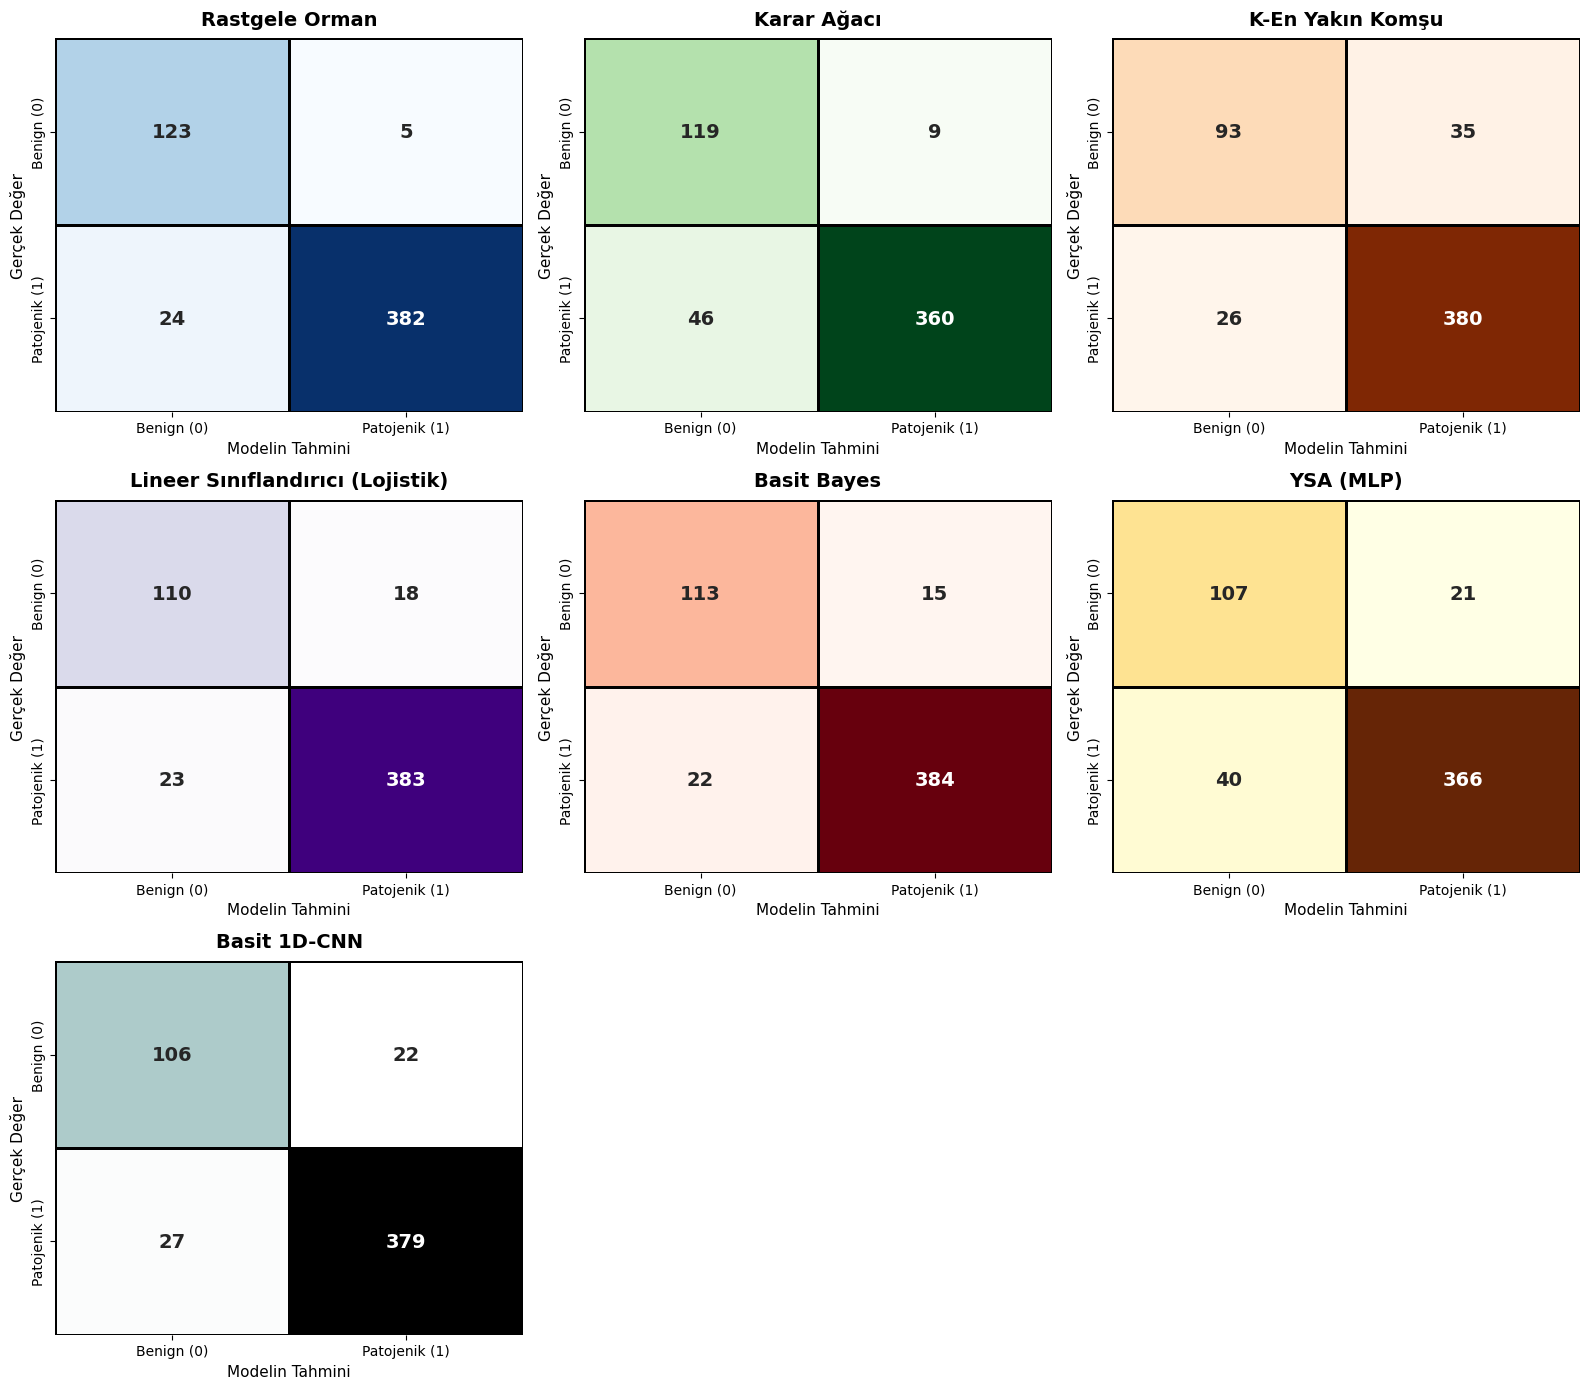

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(" Modellerin Karmaşıklık Matrisleri")

# TÜM TAHMİNLERİ BİR SÖZLÜKTE TOPLAYALIM
# Önce klasik modellerin tahminlerini yeniden alıp sözlüğe kaydediyoruz
all_predictions = {}

for model_name, model in models.items():
    # Modellerimiz 'models' sözlüğünde eğitilmiş halde duruyordu
    y_pred = model.predict(X_tab_test_scaled)
    all_predictions[model_name] = y_pred

# CNN modelimizin tahminlerini de bu sözlüğe ekliyoruz
all_predictions["Basit 1D-CNN"] = y_pred_cnn

#GÖRSELLEŞTİRME İÇİN RENK PALETLERİ VE AYARLAR
# 7 modelimiz olduğu için 7 farklı ve şık seaborn renk paleti (cmap) seçiyoruz
color_maps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlOrBr', 'bone_r']

# Matrislerin çizileceği devasa çerçeveyi ayarlıyoruz (3 satır, 3 sütun)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten() # Döngüde kolay dönmek için eksenleri düzleştiriyoruz

#MATRİSLERİ ÇİZME DÖNGÜSÜ
for i, (model_name, y_pred) in enumerate(all_predictions.items()):
    # Karmaşıklık matrisini hesapla
    cm = confusion_matrix(y_test, y_pred)
    
    # Isı haritasını (Heatmap) çiz
    sns.heatmap(cm, annot=True, fmt="d", cmap=color_maps[i], ax=axes[i], 
                cbar=False, annot_kws={"size": 14, "weight": "bold"},
                linewidths=1, linecolor='black')
    
    # Eksen isimleri ve başlıklar
    axes[i].set_title(f"{model_name}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Modelin Tahmini", fontsize=11)
    axes[i].set_ylabel("Gerçek Değer", fontsize=11)
    axes[i].set_xticklabels(['Benign (0)', 'Patojenik (1)'])
    axes[i].set_yticklabels(['Benign (0)', 'Patojenik (1)'])

# Fazladan kalan (boş) grafik pencerelerini görünmez yap
for j in range(len(all_predictions), 9):
    fig.delaxes(axes[j])

# Tasarımı sıkılaştır ve göster
plt.tight_layout()
plt.show()

Tüm Modellerin Karşılaştırmalı Performansı


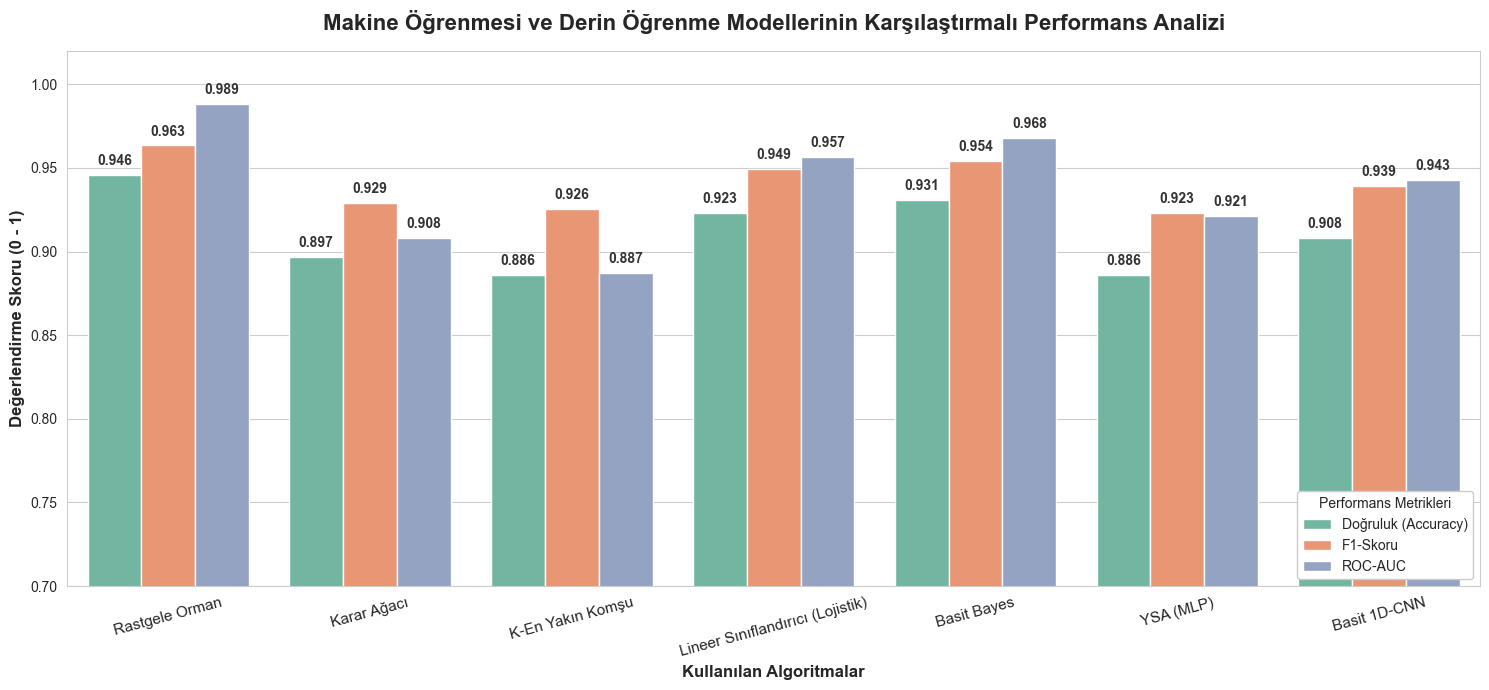

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Tüm Modellerin Karşılaştırmalı Performansı")

# Daha önce eğitilmiş olan 1D-CNN skorlarını da ana tabloya ekleyelim
try:
    results_detailed.append({
        "Model": "Basit 1D-CNN",
        "Doğruluk (Accuracy)": cnn_acc,
        "F1-Skoru": cnn_f1,
        "ROC-AUC": cnn_auc
    })
except NameError:
    print("Uyarı: CNN skorları (cnn_acc vb.) hafızada bulunamadı. Lütfen CNN eğitim kodunu çalıştırdığınızdan emin olun.")

# Listeyi Pandas DataFrame'e çeviriyoruz
df_results = pd.DataFrame(results_detailed)

# Seaborn kütüphanesinin çoklu bar grafiği çizebilmesi için veriyi melt işlemiyle uygun formata getiriyoruz
df_melted = df_results.melt(id_vars="Model", var_name="Metrik", value_name="Skor")

# Grafik Ayarları
plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")


ax = sns.barplot(data=df_melted, x="Model", y="Skor", hue="Metrik", palette="Set2")

# Başlık ve Eksen İsimlendirmeleri
plt.title("Makine Öğrenmesi ve Derin Öğrenme Modellerinin Karşılaştırmalı Performans Analizi", fontsize=16, fontweight='bold', pad=15)
plt.ylim(0.70, 1.02) # Farkların daha net görünmesi için Y eksenini 0.70'den başlatıyoruz
plt.ylabel("Değerlendirme Skoru (0 - 1)", fontsize=12, fontweight='bold')
plt.xlabel("Kullanılan Algoritmalar", fontsize=12, fontweight='bold')
plt.xticks(rotation=15, fontsize=11) # İsimler birbirine girmesin diye hafif eğik yazdırıyoruz

# Sütunların tam tepesine skorları yazdıran döngü
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Sadece 0'dan büyük değerleri yazdır
        ax.annotate(f'{height:.3f}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 10), textcoords='offset points', 
                    fontsize=10, fontweight='bold', color='#333333')

# Lejant (Bilgi Kutusu) ayarı
plt.legend(title="Performans Metrikleri", loc='lower right', framealpha=1)

plt.tight_layout()
plt.show()

Tüm Modeller İçin Dinamik Karar Eşiği (Threshold) Analizi
Modellerin Otomatik Bulunan En İyi Karar Eşikleri (Max F1'e Göre):
-------------------------------------------------------------------------------------
Model Adı                           | En İyi Eşik  | Yeni Acc   | Yeni F1    | ROC-AUC   
-------------------------------------------------------------------------------------
Rastgele Orman                      | 0.30         | %94.57     | 0.9646     | 0.9885    
Karar Ağacı                         | 0.10         | %89.70     | 0.9290     | 0.9082    
K-En Yakın Komşu                    | 0.20         | %88.39     | 0.9271     | 0.8873    
Lineer Sınıflandırıcı (Lojistik)    | 0.40         | %92.51     | 0.9509     | 0.9566    
Basit Bayes                         | 0.60         | %93.45     | 0.9564     | 0.9680    
YSA (MLP)                           | 0.10         | %90.64     | 0.9390     | 0.9213    
Basit 1D-CNN                        | 0.30         | %92.13     | 0.9495 

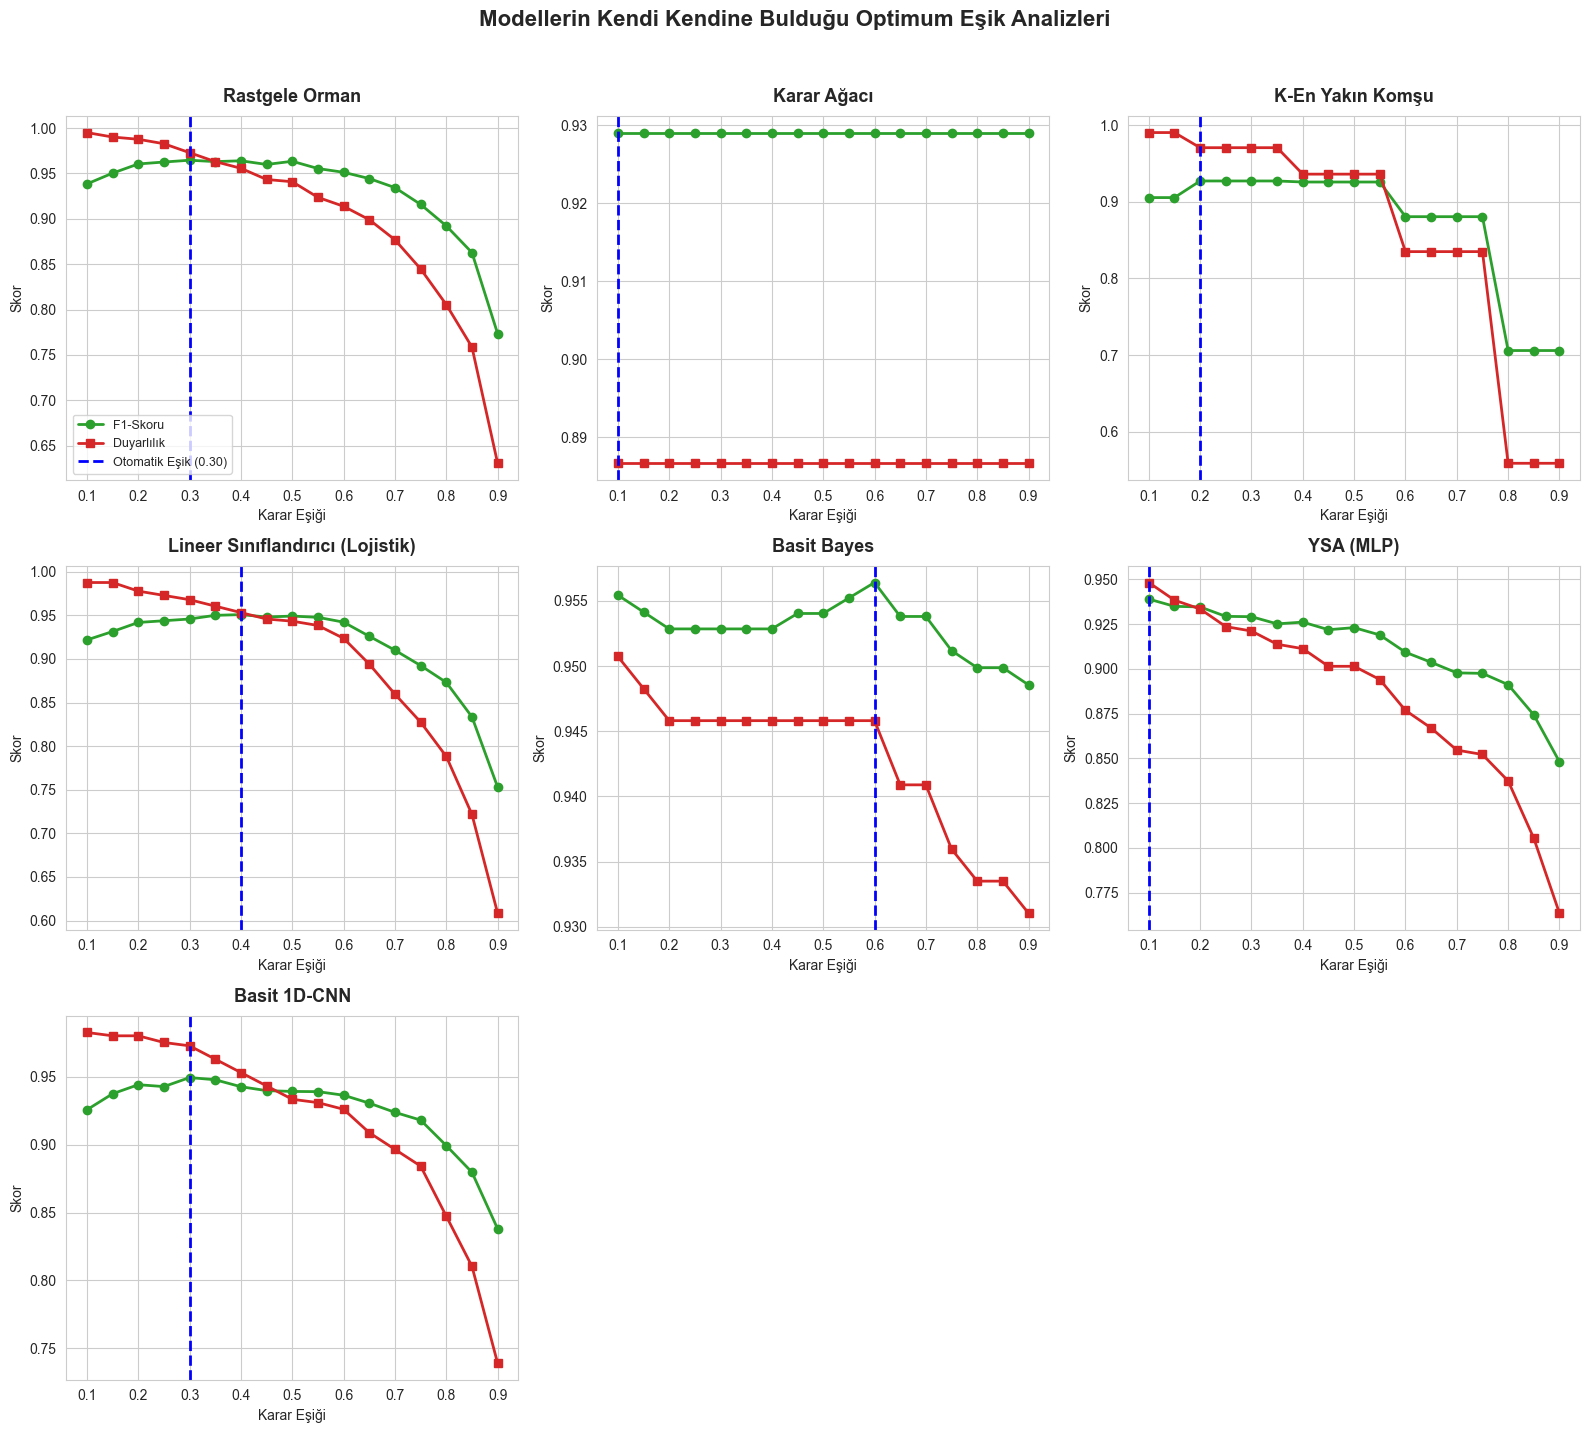

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, confusion_matrix, accuracy_score, roc_auc_score

print("Tüm Modeller İçin Dinamik Karar Eşiği (Threshold) Analizi")
all_probabilities = {}
for model_name, model in models.items():
    all_probabilities[model_name] = model.predict_proba(X_tab_test_scaled)[:, 1]

if len(y_pred_prob.shape) > 1:
    all_probabilities["Basit 1D-CNN"] = y_pred_prob.flatten()
else:
    all_probabilities["Basit 1D-CNN"] = y_pred_prob


# HER MODEL İÇİN "EN İYİ" EŞİĞİOTOMATİK BULMA

thresholds = np.arange(0.10, 0.95, 0.05)
all_thresh_results = {} 
best_thresholds = {} # Her modelin kendi "Altın Eşiğini" tutacak sözlük

for model_name, probs in all_probabilities.items():
    thresh_results = []
    for t in thresholds:
        y_pred_t = (probs > t).astype(int)
        f1 = f1_score(y_test, y_pred_t)
        recall = recall_score(y_test, y_pred_t)
        cm = confusion_matrix(y_test, y_pred_t)
        fn = cm[1, 0] # Yanlış Negatif
        
        thresh_results.append({'Karar Eşiği': t, 'F1-Skoru': f1, 'Duyarlılık': recall, 'Yanlış Negatif (FN)': fn})
    
    df_thresh = pd.DataFrame(thresh_results)
    all_thresh_results[model_name] = df_thresh
    
    #F1-Skorunun en yüksek olduğu satırı bul ve o eşiği kaydet
    best_row = df_thresh.loc[df_thresh['F1-Skoru'].idxmax()]
    best_thresholds[model_name] = best_row['Karar Eşiği']

# Otomatik bulunan en iyi eşikleri ve skorları yazdır
print("Modellerin Otomatik Bulunan En İyi Karar Eşikleri (Max F1'e Göre):")
print("-" * 85)
print(f"{'Model Adı':<35} | {'En İyi Eşik':<12} | {'Yeni Acc':<10} | {'Yeni F1':<10} | {'ROC-AUC':<10}")
print("-" * 85)

all_predictions_dynamic = {} # Yeni eşiklerle yapılan nihai tahminler (0 veya 1)

for model_name, probs in all_probabilities.items():
    best_t = best_thresholds[model_name]
    
    # Bulunan özel eşiğe göre modeli yeniden değerlendiriyoruz
    y_pred_dynamic = (probs > best_t).astype(int)
    all_predictions_dynamic[model_name] = y_pred_dynamic
    
    # Yeni Skorlar
    acc_new = accuracy_score(y_test, y_pred_dynamic)
    f1_new = f1_score(y_test, y_pred_dynamic)
    auc_score = roc_auc_score(y_test, probs)
    
    print(f"{model_name:<35} | {best_t:<12.2f} | %{acc_new*100:<9.2f} | {f1_new:<10.4f} | {auc_score:<10.4f}")
print("-" * 85)

#DİNAMİK EŞİKLERE GÖRE 3X3 GRAFİK ÇİZİMİ

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()
sns.set_style("whitegrid")

for i, (model_name, df_thresh) in enumerate(all_thresh_results.items()):
    ax = axes[i]
    best_t = best_thresholds[model_name] # O modelin kendi özel eşiği
    
    ax.plot(df_thresh['Karar Eşiği'], df_thresh['F1-Skoru'], label='F1-Skoru', marker='o', color='#2ca02c', linewidth=2)
    ax.plot(df_thresh['Karar Eşiği'], df_thresh['Duyarlılık'], label='Duyarlılık', marker='s', color='#d62728', linewidth=2)
    
    # Çizgiyi modelin KENDİ bulduğu en iyi eşiğe çekiyoruz!
    ax.axvline(x=best_t, color='blue', linestyle='--', linewidth=2, label=f'Otomatik Eşik ({best_t:.2f})')
    
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Karar Eşiği', fontsize=10)
    ax.set_ylabel('Skor', fontsize=10)
    ax.set_xticks(np.arange(0.10, 0.95, 0.10))
    if i == 0: ax.legend(loc='lower left', fontsize=9)

for j in range(len(all_thresh_results), 9): fig.delaxes(axes[j])
plt.suptitle('Modellerin Kendi Kendine Bulduğu Optimum Eşik Analizleri', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



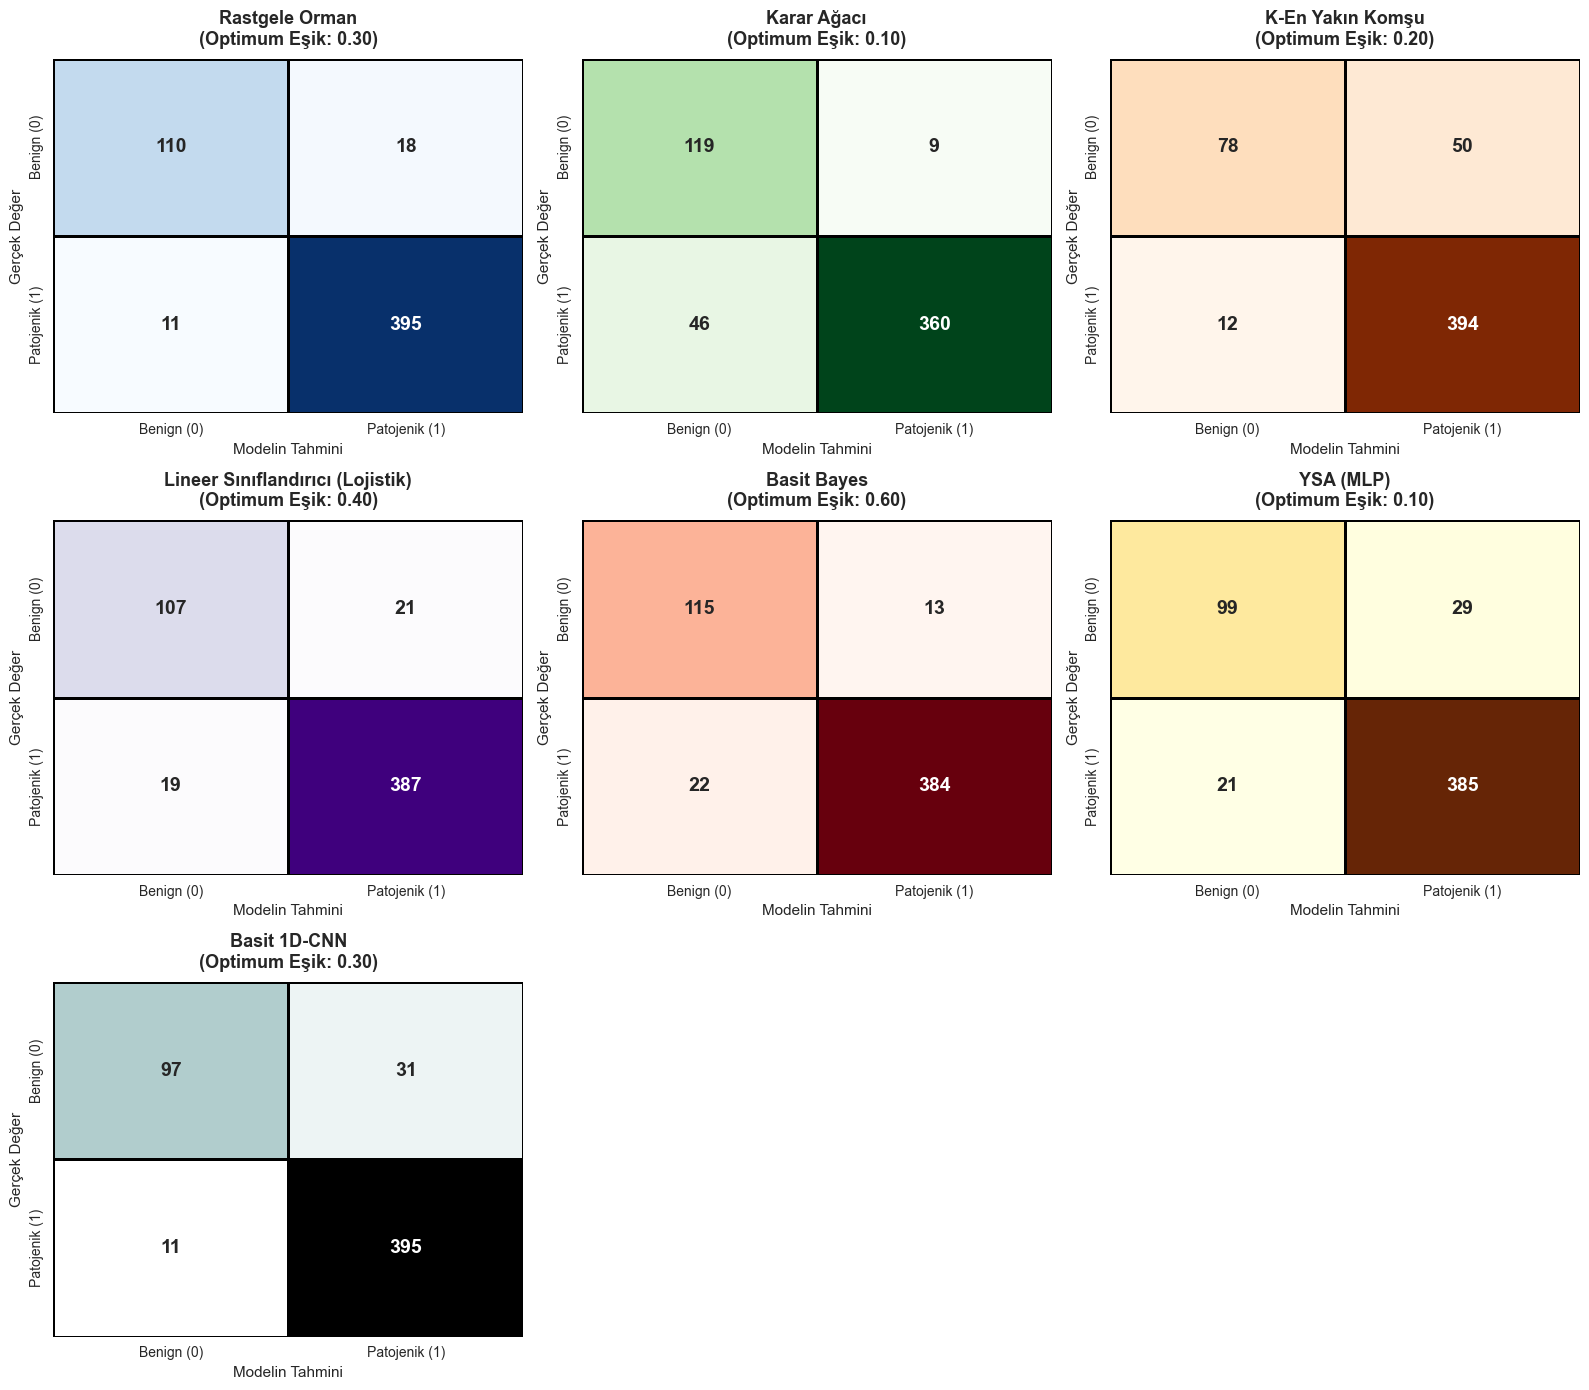

In [31]:
#Optimum Eşiklere Göre Güncellenmiş Karmaşıklık Matrisleri

color_maps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlOrBr', 'bone_r']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, (model_name, y_pred_dyn) in enumerate(all_predictions_dynamic.items()):
    cm = confusion_matrix(y_test, y_pred_dyn)
    best_t = best_thresholds[model_name]
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=color_maps[i], ax=axes[i], 
                cbar=False, annot_kws={"size": 14, "weight": "bold"},
                linewidths=1, linecolor='black')
    
    # Başlığa o modelin hangi eşiği kullandığını da yazdırıyoruz
    axes[i].set_title(f"{model_name}\n(Optimum Eşik: {best_t:.2f})", fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Modelin Tahmini", fontsize=11)
    axes[i].set_ylabel("Gerçek Değer", fontsize=11)
    axes[i].set_xticklabels(['Benign (0)', 'Patojenik (1)'])
    axes[i].set_yticklabels(['Benign (0)', 'Patojenik (1)'])

for j in range(len(all_predictions_dynamic), 9): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

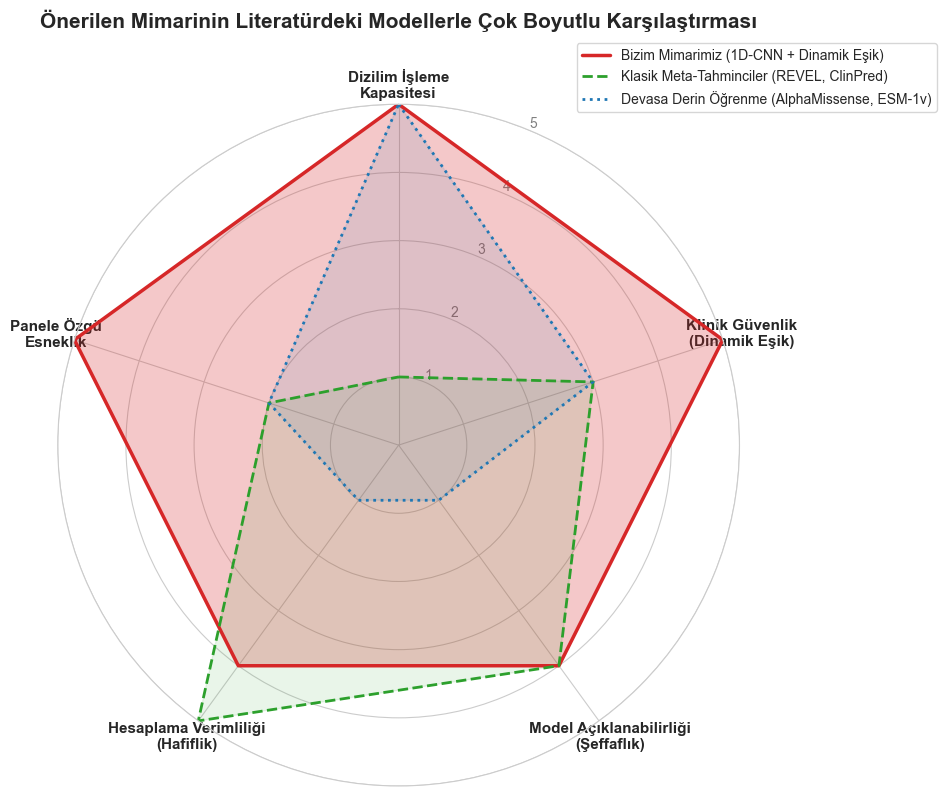

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Karşılaştırılacak Kategoriler
labels = [
    'Dizilim İşleme\nKapasitesi', 
    'Klinik Güvenlik\n(Dinamik Eşik)', 
    'Model Açıklanabilirliği\n(Şeffaflık)', 
    'Hesaplama Verimliliği\n(Hafiflik)', 
    'Panele Özgü\nEsneklik'
]

# Modellerin 1-5 arası Puanlaması 
# 1: Çok Zayıf, 5: Çok Güçlü

# Bizim Modelimiz (1D-CNN + Dinamik Eşik)
bizim_model = [5, 5, 4, 4, 5] 

# Klasik Meta-Predictor'lar (Örn: REVEL, ClinPred)
klasik_modeller = [1, 3, 4, 5, 2] 

# Devasa Dil Modelleri (Örn: AlphaMissense, ESM-1v)
dev_modeller = [5, 3, 1, 1, 2] 

# Radar grafiği için açıları hesaplama 
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Çizgilerin kapalı bir poligon oluşturması için ilk değeri sona ekliyoruz
bizim_model += bizim_model[:1]
klasik_modeller += klasik_modeller[:1]
dev_modeller += dev_modeller[:1]
angles += angles[:1]

# Grafik Ayarları
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

# Bizim Modelimizin Çizimi
ax.plot(angles, bizim_model, color='#d62728', linewidth=2.5, linestyle='solid', label='Bizim Mimarimiz (1D-CNN + Dinamik Eşik)')
ax.fill(angles, bizim_model, color='#d62728', alpha=0.25)

#  Klasik Modellerin Çizimi (REVEL vb.)
ax.plot(angles, klasik_modeller, color='#2ca02c', linewidth=2, linestyle='dashed', label='Klasik Meta-Tahminciler (REVEL, ClinPred)')
ax.fill(angles, klasik_modeller, color='#2ca02c', alpha=0.1)

#  Devasa Dil Modellerinin Çizimi (AlphaMissense vb.)
ax.plot(angles, dev_modeller, color='#1f77b4', linewidth=2, linestyle='dotted', label='Devasa Derin Öğrenme (AlphaMissense, ESM-1v)')
ax.fill(angles, dev_modeller, color='#1f77b4', alpha=0.1)

# Eksen ayarları ve İsimlendirmeler
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], color='grey', size=10)
ax.set_ylim(0, 5)

# Başlık ve Lejant
plt.title('Önerilen Mimarinin Literatürdeki Modellerle Çok Boyutlu Karşılaştırması', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()